# Flood Baseline Notebook 

## Imports

In [1]:
import os
import logging
import json
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

## Config

In [3]:
PREPARED_DIR = Path(r"D:/Projects/datasets/raw/prepared")
SAMPLE_FILE_PREFIX = "selected_"

## Load Data

In [4]:
def get_dataset_files(prepared_dir: Path, prefix: str = "selected_") -> list[dict]:
    """Scans the directory and returns a list of dictionaries containing metadata and paths."""
    samples = []
    npz_files = sorted(prepared_dir.glob(f"{prefix}*.npz"))
    for npz_path in npz_files:
        meta_path = npz_path.with_suffix(".json")
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        meta["npz_path"] = npz_path
        samples.append(meta)
    return samples

In [5]:
def split_train_val_test(samples: list[dict], val_frac: float = 0.2, test_frac: float = 0.2):
    """Splits samples chronologically per region."""
    # Group by region
    by_region = {}
    for s in samples:
        by_region.setdefault(s.get("region", "unknown"), []).append(s)

    train, val, test = [], [], []
    
    for region, region_samples in by_region.items():
        # Sort each region's samples by date
        region_samples.sort(key=lambda x: x["date"])
        n_total = len(region_samples)
        
        # Calculate split indices
        n_test = max(1, int(n_total * test_frac))
        n_val = max(1, int(n_total * val_frac)) 
        n_train = n_total - n_val - n_test
        
        train.extend(region_samples[:n_train])
        val.extend(region_samples[n_train:n_train + n_val])
        test.extend(region_samples[n_train + n_val:])

    return train, val, test

In [6]:
def load_target_masks(npz_path: Path, target: str = "s1_label") -> tuple[np.ndarray, np.ndarray]:
    """Loads the ground truth label and valid pixel mask for a specific target."""
    
    data = dict(np.load(npz_path, allow_pickle=False))
    
    if target == "s1_label":
        label = data["s1_label"]
        valid = data.get("s1_label_valid", np.isfinite(label))
    elif target == "gfm_mask":
        label = data["gfm_mask"]
        valid = data.get("gfm_valid", np.isfinite(label))
    else:
        # create an empty array of shape - (1, 2522, 6274)
        label = np.zeros((1, 2522, 6274), dtype=bool)
        valid = np.zeros((1, 2522, 6274), dtype=bool)
        
    label = label[0]
    valid = valid[0]

    return label.astype(bool), valid.astype(bool)

### Run

In [7]:
samples = get_dataset_files(PREPARED_DIR, SAMPLE_FILE_PREFIX)
train_samples, val_samples, test_samples = split_train_val_test(samples)

### Test

## Analyze

### Visualize Sample

In [ ]:
def plot_sample(sample: dict,  plot_env_weather: bool = True):
    """Plots Sentinel-1 bands, S1 labels, GFM ground truth, env, and weather for a given sample."""
    npz_path = sample["npz_path"]

    with np.load(npz_path, allow_pickle=False) as data:
        s1 = data["s1"][:]
        if plot_env_weather:
            env = data["env"][:]
            weather = data["weather"][:]
        
    vv = s1[0]
    vh = s1[1] if s1.shape[0] > 1 else s1[0]

    
    if plot_env_weather:
        fig, axes = plt.subplots(5, 5, figsize=(20, 20))
    else:
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
    axes = axes.flatten()

    axes[0].imshow(vv, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("S1 VV (Normalized)")

    axes[1].imshow(vh, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("S1 VH (Normalized)")

    s1_label, _ = load_target_masks(npz_path, target="s1_label")
    axes[2].imshow(s1_label, cmap="Blues", interpolation="none")
    axes[2].set_title("S1 Label")

    gfm_label, _ = load_target_masks(npz_path, target="gfm_mask")
    axes[3].imshow(gfm_label, cmap="Reds", interpolation="none")
    axes[3].set_title("GFM Ground Truth")

    # --- Plot Env Data (Indices 4 to 18) ---
    if plot_env_weather:
        for i in range(15):
            axes[4 + i].imshow(env[i], cmap="viridis", vmin=0, vmax=1)
            axes[4 + i].set_title(f"Env Band {i}")
        for i in range(6):
            axes[19 + i].imshow(weather[i], cmap="magma")
            axes[19 + i].set_title(f"Weather Band {i}")

    # Clean up axes
    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"Sample: {sample.get('sample_id')} | {sample.get('date')}", y=0.98, fontsize=16)
    plt.tight_layout()
    plt.show()

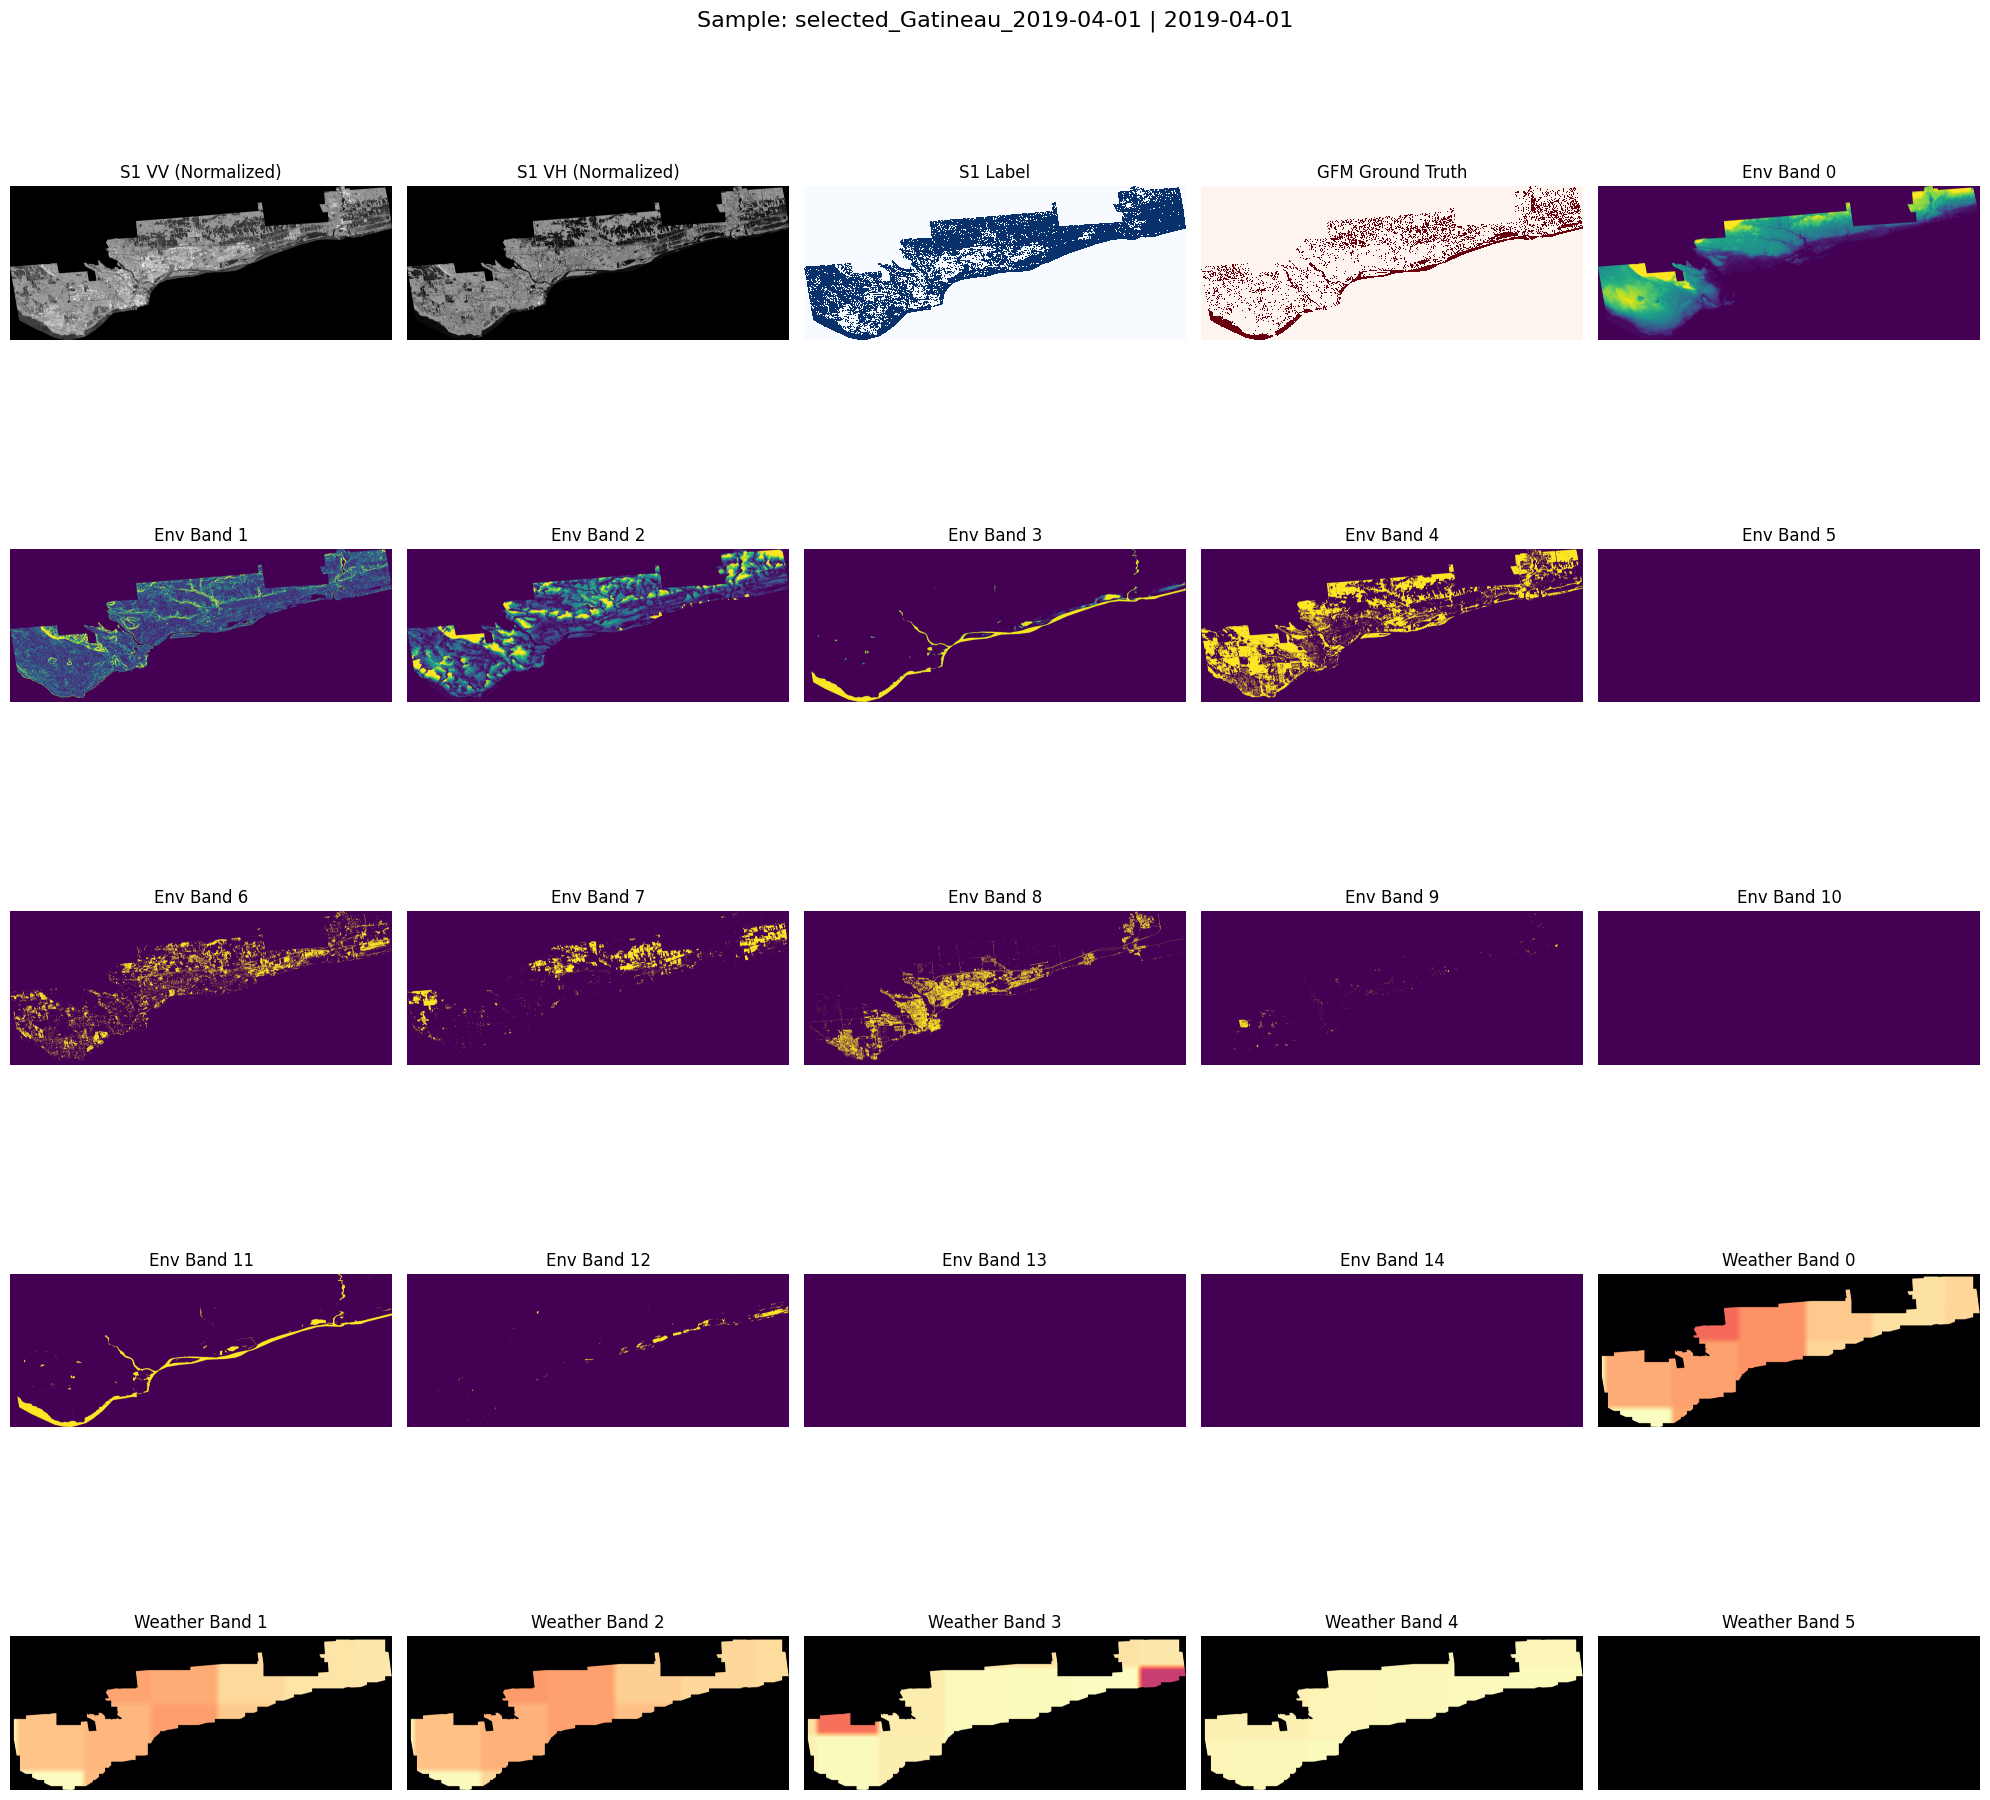

In [ ]:
plot_sample(train_samples[0], plot_env_weather=True)

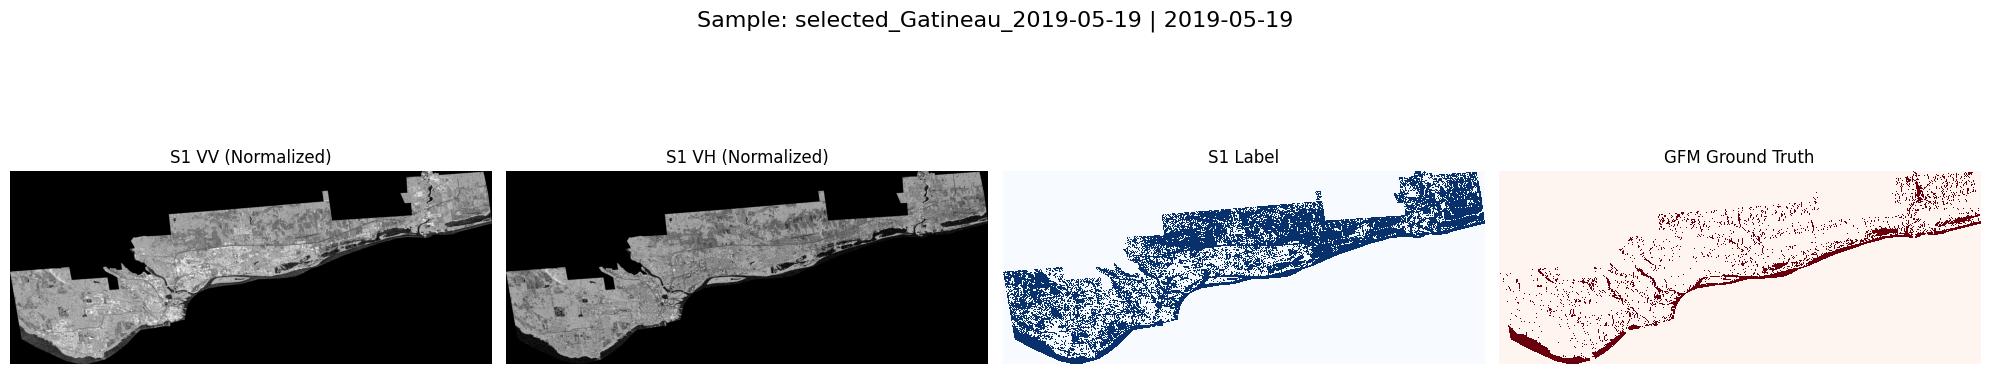

In [ ]:
plot_sample(test_samples[0], plot_env_weather=False)

### Analyze labels

In [ ]:
def analyze_dataset_and_features(samples: list[dict], split_name: str, max_intensity_files: int = 20, max_points: int = 50000) -> pd.DataFrame:
    fraction_results = []
    pos_vv_s1, pos_vh_s1, neg_vv_s1, neg_vh_s1 = [], [], [], []
    pos_vv_gfm, pos_vh_gfm, neg_vv_gfm, neg_vh_gfm = [], [], [], []

    for i, sample in enumerate(samples):
        npz_path = sample["npz_path"]
        
        with np.load(npz_path, allow_pickle=False) as data:
            s1 = data["s1"][:]
            
            # Calculate Fractions (Executes for all samples)
            s1_label, s1_valid = load_target_masks(npz_path, target="s1_label")
            s1_valid_count = s1_valid.sum()
            s1_frac = s1_label[s1_valid].mean() if s1_valid_count > 0 else np.nan

            gfm_label, gfm_valid = load_target_masks(npz_path, target="gfm_mask")
            gfm_valid_count = gfm_valid.sum()
            gfm_frac = gfm_label[gfm_valid].mean() if gfm_valid_count > 0 else np.nan

            fraction_results.append({
                "sample_id": sample.get("sample_id"),
                "s1_flood_fraction": s1_frac,
                "gfm_flood_fraction": gfm_frac
            })

            # Extract Intensities 
            if i < max_intensity_files:
                vv = s1[0]
                vh = s1[1] if s1.shape[0] > 1 else s1[0]
                
                is_flood_s1 = s1_valid & s1_label
                not_flood_s1 = s1_valid & (~s1_label)

                is_flood_gfm = gfm_valid & gfm_label
                not_flood_gfm = gfm_valid & (~gfm_label)

                pos_vv_s1.append(vv[is_flood_s1])
                pos_vh_s1.append(vh[is_flood_s1])
                neg_vv_s1.append(vv[not_flood_s1])
                neg_vh_s1.append(vh[not_flood_s1])

                pos_vv_gfm.append(vv[is_flood_gfm])
                pos_vh_gfm.append(vh[is_flood_gfm])
                neg_vv_gfm.append(vv[not_flood_gfm])
                neg_vh_gfm.append(vh[not_flood_gfm])

    # --- Aggregation and Plotting ---
    df_fractions = pd.DataFrame(fraction_results)

    # Concatenate S1 lists to numpy arrays
    pos_vv_s1, pos_vh_s1 = np.concatenate(pos_vv_s1), np.concatenate(pos_vh_s1)
    neg_vv_s1, neg_vh_s1 = np.concatenate(neg_vv_s1), np.concatenate(neg_vh_s1)
    
    # Concatenate GFM lists to numpy arrays
    pos_vv_gfm, pos_vh_gfm = np.concatenate(pos_vv_gfm), np.concatenate(pos_vh_gfm)
    neg_vv_gfm, neg_vh_gfm = np.concatenate(neg_vv_gfm), np.concatenate(neg_vh_gfm)
    
    # Subsample intensities to prevent plotting bottleneck
    idx_pos = np.random.choice(len(pos_vv_s1), max_points, replace=False)
    pos_vv_s1, pos_vh_s1 = pos_vv_s1[idx_pos], pos_vh_s1[idx_pos]
    
    idx_neg = np.random.choice(len(neg_vv_s1), max_points, replace=False)
    neg_vv_s1, neg_vh_s1 = neg_vv_s1[idx_neg], neg_vh_s1[idx_neg]

    idx_pos = np.random.choice(len(pos_vv_gfm), max_points, replace=False)
    pos_vv_gfm, pos_vh_gfm = pos_vv_gfm[idx_pos], pos_vh_gfm[idx_pos]

    idx_neg = np.random.choice(len(neg_vv_gfm), max_points, replace=False)
    neg_vv_gfm, neg_vh_gfm = neg_vv_gfm[idx_neg], neg_vh_gfm[idx_neg]

    # Render Plot 1: Dataset Fractions
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_fractions["s1_flood_fraction"].dropna(), bins=20, color="steelblue")
    axes[0].set_title(f"{split_name.upper()}: S1 Flood Fraction")
    axes[1].hist(df_fractions["gfm_flood_fraction"].dropna(), bins=20, color="salmon")
    axes[1].set_title(f"{split_name.upper()}: GFM Flood Fraction")
    plt.show()

    # Render Plot 2: Intensity Distributions for S1 and GFM
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8))

    axes2[0][0].hist(neg_vv_s1, bins=50, alpha=0.5, label="Non-Flood", density=True, color="gray")
    axes2[0][0].hist(pos_vv_s1, bins=50, alpha=0.5, label="Flood", density=True, color="royalblue")
    axes2[0][0].set_title("VV Intensity Distribution for S1")
    axes2[0][0].legend()
    
    axes2[0][1].hist(neg_vh_s1, bins=50, alpha=0.5, label="Non-Flood", density=True, color="gray")
    axes2[0][1].hist(pos_vh_s1, bins=50, alpha=0.5, label="Flood", density=True, color="royalblue")
    axes2[0][1].set_title("VH Intensity Distribution for S1")
    axes2[0][1].legend()
    
    # Render Plot 3: Intensity Distributions for GFM
    axes2[1][0].hist(neg_vv_gfm, bins=50, alpha=0.5, label="Non-Flood", density=True, color="gray")
    axes2[1][0].hist(pos_vv_gfm, bins=50, alpha=0.5, label="Flood", density=True, color="royalblue")
    axes2[1][0].set_title("VV Intensity Distribution for GFM")
    axes2[1][0].legend()
    
    axes2[1][1].hist(neg_vh_gfm, bins=50, alpha=0.5, label="Non-Flood", density=True, color="gray")
    axes2[1][1].hist(pos_vh_gfm, bins=50, alpha=0.5, label="Flood", density=True, color="royalblue")
    axes2[1][1].set_title("VH Intensity Distribution for GFM")
    axes2[1][1].legend()
    
    plt.tight_layout()
    plt.show()

    return df_fractions

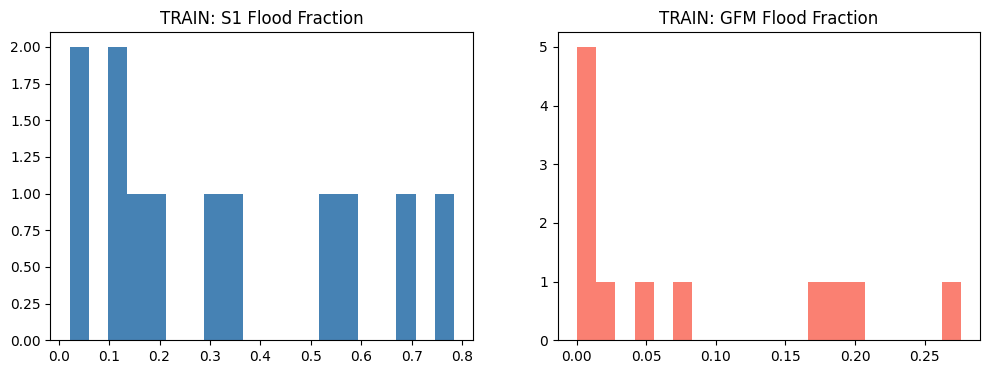

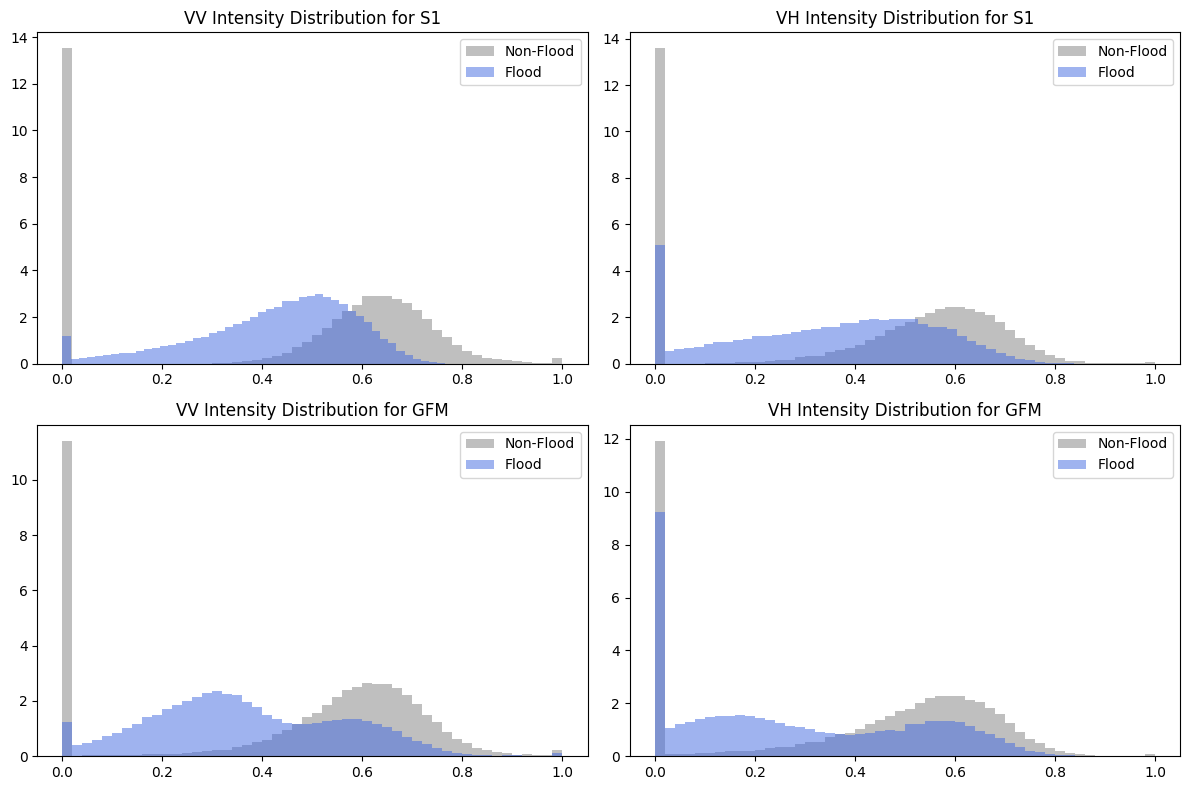

,sample_id,s1_flood_fraction,gfm_flood_fraction
0,selected_Gatineau_2019-04-01,0.783895,0.276392
1,selected_Gatineau_2019-04-08,0.206567,0.023557
2,selected_Gatineau_2019-04-13,0.703923,0.188051
3,selected_Gatineau_2019-04-25,0.345322,0.177301
4,selected_Gatineau_2019-04-26,0.527203,0.003080
5,selected_Gatineau_2019-05-02,0.104937,0.005825
6,selected_Ottawa_2019-04-01,0.592524,0.199216
7,selected_Ottawa_2019-04-08,0.118693,0.010430
8,selected_Ottawa_2019-04-13,0.301143,0.042087
9,selected_Ottawa_2019-04-25,0.153589,0.076642


In [ ]:
analyze_dataset_and_features(train_samples, "train")

In [8]:
print(f"Train samples: {len(train_samples)}")
print(f"Val samples: {len(val_samples)}")
print(f"Test samples: {len(test_samples)}")
print(f"Columns: {train_samples[0].keys()}")

Train samples: 12
Val samples: 4
Test samples: 4
Columns: dict_keys(['sample_id', 'region', 'date', 'shape_by_key', 'pos_weight', 'positive_ratio', 'crs', 'transform', 'npz_path'])


In [9]:
label, valid = load_target_masks(samples[0]["npz_path"], target="gfm_mask")

In [10]:
sample_metadata = train_samples[0]
npz_path = sample_metadata["npz_path"]

print("--- Sample Metadata ---")
for key, value in sample_metadata.items():
    print(f"{key}: {value}")

print("\n--- Inspecting Raw Arrays ---")
with np.load(npz_path, allow_pickle=False) as data:
    print(f"Available keys in archive: {data.files}")
    s1_array = data["s1"][:]
    print(f"S1 Array Shape (Channels, Height, Width): {s1_array.shape}")
    print(f"S1 Array Data Type: {s1_array.dtype}")

--- Sample Metadata ---
sample_id: selected_Gatineau_2019-04-01
region: Gatineau
date: 2019-04-01
shape_by_key: {'s1': [2, 2522, 6274], 's1_label': [1, 2522, 6274], 'env': [15, 2522, 6274], 'hydro': [1, 2522, 6274], 'weather': [6, 2522, 6274], 'glofas': [1, 2522, 6274], 'gfm_mask': [1, 2522, 6274], 's1_label_valid': [1, 2522, 6274], 'gfm_valid': [1, 2522, 6274]}
pos_weight: 1.0
positive_ratio: 0.0
crs: EPSG:4326
transform: [8.983152841195215e-05, 0.0, -75.90880931796892, 0.0, -8.983152841195215e-05, 45.59920247413421, 0.0, 0.0, 1.0]
npz_path: D:\Projects\datasets\raw\prepared\selected_Gatineau_2019-04-01.npz

--- Inspecting Raw Arrays ---
Available keys in archive: ['s1', 's1_label', 'env', 'hydro', 'weather', 'glofas', 'gfm_mask', 's1_label_valid', 'gfm_valid']
S1 Array Shape (Channels, Height, Width): (2, 2522, 6274)
S1 Array Data Type: float32


## Define Eval Metrics

In [8]:
def plot_evaluation_metrics(y_true: np.ndarray, y_pred: np.ndarray, target: str):
    """Renders confusion matrix, precision-recall, and ROC curves for global arrays."""

    # Confusion Matrix (Calculated exactly once)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(3, 3))
    # Corrected labels: 0=Non-Flood, 1=Flood
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Flood", "Flood"], yticklabels=["Non-Flood", "Flood"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix ({target.upper()})")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    plt.figure(figsize=(3, 3))
    plt.plot(recall, precision, label="Precision-Recall Curve", color="purple")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.title(f"PR Curve ({target.upper()})")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    plt.figure(figsize=(3, 3))
    plt.plot(fpr, tpr, label="ROC Curve", color="darkorange")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.title(f"ROC Curve ({target.upper()})")
    plt.show()

In [9]:
def evaluate_predictions(predictions_dict: dict, samples: list[dict], target: str = "s1_label") -> pd.DataFrame:
    """Evaluates predicted masks against ground truth and delegates global plotting."""
    results = []
    
    # Local states for fast numpy accumulation
    y_true_list = []
    y_pred_list = []

    for sample in samples:
        sample_id = sample.get("sample_id")
        if sample_id not in predictions_dict:
            continue

        # Load the true labels and valid mask from disk
        y_ref, valid_mask = load_target_masks(sample["npz_path"], target=target)
        
        # Apply the valid mask
        y_true = y_ref[valid_mask]
        y_pred = predictions_dict[sample_id][valid_mask].astype(bool)

        # Fast numpy logic for local metrics
        tp = (y_true & y_pred).sum()
        fp = (~y_true & y_pred).sum()
        fn = (y_true & ~y_pred).sum()
        
        eps = 1e-8
        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)

        results.append({
            "sample_id": sample_id,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })
        
        # O(1) list appends of contiguous memory blocks
        y_true_list.append(y_true)
        y_pred_list.append(y_pred)

    # Single O(N) concatenation for global metrics
    y_true_global = np.concatenate(y_true_list)
    y_pred_global = np.concatenate(y_pred_list)

    # Print and Plot
    print(f"\n--- Global Evaluation Report ({target.upper()}) ---")
    print(classification_report(y_true_global, y_pred_global, zero_division=0))
    plot_evaluation_metrics(y_true_global, y_pred_global, target)
    
    return pd.DataFrame(results)

In [10]:
def evaluate_predictions_fast(predictions_dict: dict, samples: list[dict], target: str = "s1") -> pd.DataFrame:
    """Evaluates predicted masks instantly by aggregating local TP/FP/FN/TN integer counts."""
    results = []
    
    # Local states for O(1) global aggregation
    g_tp, g_fp, g_fn, g_tn = 0, 0, 0, 0

    for sample in samples:
        sample_id = sample.get("sample_id")
        if sample_id not in predictions_dict:
            continue

        # Load the true labels and valid mask from disk
        y_ref, valid_mask = load_target_masks(sample["npz_path"], target=target)
        
        # Apply the valid mask
        y_true = y_ref[valid_mask]
        y_pred = predictions_dict[sample_id][valid_mask].astype(bool)

        # Fast numpy logic for local metrics
        tp = (y_true & y_pred).sum()
        fp = (~y_true & y_pred).sum()
        fn = (y_true & ~y_pred).sum()
        tn = (~y_true & ~y_pred).sum()
        
        # Accumulate global integer counts
        g_tp += tp
        g_fp += fp
        g_fn += fn
        g_tn += tn
        
        eps = 1e-8
        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)

        results.append({
            "sample_id": sample_id,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    # Calculate Global Metrics via integer arithmetic
    eps = 1e-8
    g_precision = g_tp / (g_tp + g_fp + eps)
    g_recall = g_tp / (g_tp + g_fn + eps)
    g_f1 = 2 * g_precision * g_recall / (g_precision + g_recall + eps)

    # Print Global Report
    print(f"\n--- Global Evaluation Report ({target.upper()}) ---")
    print(f"Precision: {g_precision:.4f} | Recall: {g_recall:.4f} | F1-Score: {g_f1:.4f}")

    # Render pre-calculated Confusion Matrix
    cm = np.array([[g_tn, g_fp], [g_fn, g_tp]])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Flood", "Flood"], yticklabels=["Non-Flood", "Flood"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Global Confusion Matrix ({target.upper()})")
    plt.show()
    
    return pd.DataFrame(results)

 ## Threshold Baseline

In [35]:
# Generate Predictions (Threshold baseline)
predictions_thresh = {}

for s in test_samples:
    s1_label, s1_valid = load_target_masks(s["npz_path"], target="s1_label")
    predictions_thresh[s["sample_id"]] = s1_label  


--- Global Evaluation Report (GFM_MASK) ---
Precision: 0.1015 | Recall: 0.8130 | F1-Score: 0.1805


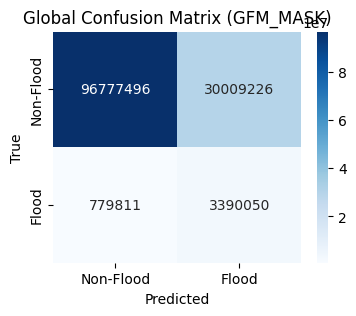

,sample_id,precision,recall,f1
0,selected_Gatineau_2019-05-19,0.234260,0.889341,0.370838
1,selected_Gatineau_2019-05-26,0.044286,0.987586,0.084770
2,selected_Ottawa_2019-05-19,0.108200,0.788413,0.190286
3,selected_Ottawa_2019-05-26,0.001124,0.994365,0.002246


In [36]:
# Evaluate against GFM target
df_eval_thresh = evaluate_predictions_fast(
    predictions_dict=predictions_thresh, 
    samples=test_samples, 
    target="gfm_mask"
)

display(df_eval_thresh)

## ML Baseline

### Prepare data

In [37]:
def extract_pixel_features(npz_path: Path, target: str = "s1_label", max_pixels: int = 50000) -> tuple[np.ndarray, np.ndarray]:
    """Extracts flattened VV, VH features and labels for valid pixels."""
    # Load input S1 data safely
    with np.load(npz_path, allow_pickle=False) as data:
        s1 = data["s1"][:]
        
    # Explicitly define shape and flatten spatial dimensions
    channels, height, width = s1.shape
    vv = s1[0].flatten()
    vh = s1[1].flatten() if channels > 1 else s1[0].flatten()
    
    # Load targets and valid masks
    label_2d, valid_2d = load_target_masks(npz_path, target=target)
    label = label_2d.flatten()
    valid = valid_2d.flatten()
    
    # Filter to retain only valid pixels
    vv_valid = vv[valid]
    vh_valid = vh[valid]
    y_valid = label[valid]
    
    # Stack into feature matrix X (N_pixels, 2 features)
    X_valid = np.column_stack((vv_valid, vh_valid))
    
    # Subsample to prevent Out-Of-Memory errors during training
    if len(y_valid) > max_pixels:
        indices = np.random.choice(len(y_valid), max_pixels, replace=False)
        X_valid = X_valid[indices]
        y_valid = y_valid[indices]
        
    return X_valid, y_valid

In [38]:
def build_training_set(samples: list[dict], target: str = "s1_label", pixels_per_image: int = 50000) -> tuple[np.ndarray, np.ndarray]:
    """Iterates through samples to build global X_train and y_train matrices."""
    X_list = []
    y_list = []
    
    for sample in samples:
        npz_path = sample["npz_path"]
        X, y = extract_pixel_features(npz_path, target=target, max_pixels=pixels_per_image)
        
        X_list.append(X)
        y_list.append(y)
        
    # Precondition assertion
    assert len(X_list) > 0, "No training data was extracted. Check sample paths."
    
    # Concatenate all local state arrays into global training matrices
    X_train = np.vstack(X_list)
    y_train = np.concatenate(y_list)
    
    return X_train, y_train

In [39]:
# Build the training set from the train_samples
print("Extracting training features...")
X_train, y_train = build_training_set(train_samples, target="s1_label", pixels_per_image=50000)
print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

Extracting training features...
Training data shape: X=(600000, 2), y=(600000,)


### Define Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=50,       # Keep it relatively low for faster baseline execution
    max_depth=10,          # Prevent extreme overfitting to speckle noise
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)

### Train

In [ ]:
# Initialize and train the Random Forest
print("Training Random Forest Classifier...")
rf_model.fit(X_train, y_train)

Training Random Forest Classifier...


,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# save model
import joblib
model_path = Path(f"../models/rf_baseline.joblib")
joblib.dump(rf_model, model_path)

# import pickle
# with open("rf_model.pkl", "wb") as f:
#     pickle.dump(rf_model, f)

['..\\models\\rf_baseline.joblib']

### Predict

In [42]:
def predict_in_batches(model, X: np.ndarray, batch_size: int = 1000000) -> np.ndarray:
    """
    Predicts labels in sequential batches to prevent Out-Of-Memory (OOM) errors.
    """
    n_samples = X.shape[0]
    predictions = []
    
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        
        # Slice the batch and predict
        X_batch = X[start_idx:end_idx]
        y_pred_batch = model.predict(X_batch)
        
        # Accumulate local states
        predictions.append(y_pred_batch)
        
    # Postcondition: Reassemble into a single 1D array
    y_pred_flat = np.concatenate(predictions)
    return y_pred_flat

In [43]:
def predict_masks_with_model(model, samples: list[dict], batch_size: int = 1000000) -> dict:
    """Generates 2D prediction masks using a trained pixel-wise model."""
    predictions = {}
    
    for sample in samples:
        npz_path = sample["npz_path"]
        
        # Safely load the array and close the connection
        with np.load(npz_path, allow_pickle=False) as data:
            s1 = data["s1"][:]
            
        # Extract shapes
        channels, height, width = s1.shape
        vv = s1[0].flatten()
        vh = s1[1].flatten() if channels > 1 else s1[0].flatten()
        
        # Stack all pixels into a massive matrix
        X_all = np.column_stack((vv, vh))
        
        # Delegate to our batched predictor to save RAM
        y_pred_flat = predict_in_batches(model, X_all, batch_size=batch_size)
        
        # Ensure the spatial reconstruction will work perfectly
        assert len(y_pred_flat) == (height * width), "Prediction length mismatch before reshape."
        
        # Reshape the 1D predictions back into the 2D image grid
        y_pred_2d = y_pred_flat.reshape((height, width))
        
        # Store in local dictionary explicitly keyed by sample_id
        predictions[sample["sample_id"]] = y_pred_2d
        
    return predictions

In [44]:
# Generate predictions on the test set
print("Generating batched predictions on test set...")
rf_predictions = predict_masks_with_model(rf_model, test_samples, batch_size=1000000)

Generating batched predictions on test set...


### Evaluate

Evaluating Baseline...

--- Global Evaluation Report (S1_LABEL) ---
Precision: 0.8114 | Recall: 0.4937 | F1-Score: 0.6139


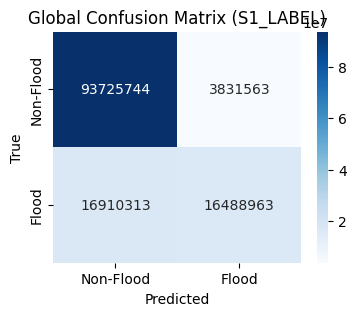

,sample_id,precision,recall,f1
0,selected_Gatineau_2019-05-19,0.995969,0.425304,0.596071
1,selected_Gatineau_2019-05-26,0.495936,0.930822,0.647100
2,selected_Ottawa_2019-05-19,0.989635,0.420761,0.590472
3,selected_Ottawa_2019-05-26,0.594614,0.774585,0.672771


In [45]:
print("Evaluating Baseline...")
df_eval_rf = evaluate_predictions_fast(
    predictions_dict=rf_predictions, 
    samples=test_samples, 
    target="s1_label" 
)

display(df_eval_rf)

## UNet

### Prepare Data

In [11]:
def extract_unet_patches(samples: list[dict], target: str = "s1_label", patch_size: int = 256, patches_per_img: int = 50) -> tuple[torch.Tensor, torch.Tensor]:
    """Explicitly extracts random 2D patches from the dataset for U-Net training."""
    X_list, y_list = [], []

    for sample in samples:
        with np.load(sample["npz_path"], allow_pickle=False) as data:
            s1 = data["s1"][:]
            label = data[target][0] if data[target].ndim == 3 else data[target]

        # Handle potential transposed arrays (from earlier EDA step)
        if s1[0].shape != label.shape:
            if s1[0].T.shape == label.shape:
                s1 = np.array([s1[0].T, s1[1].T]) if s1.shape[0] > 1 else np.array([s1[0].T])
            else:
                continue
                
        channels, h, w = s1.shape
        
        # Ensure image is large enough for the requested patch size
        if h < patch_size or w < patch_size:
            continue

        # Extract random patches
        for _ in range(patches_per_img):
            y_start = np.random.randint(0, h - patch_size)
            x_start = np.random.randint(0, w - patch_size)
            
            x_patch = s1[:, y_start:y_start+patch_size, x_start:x_start+patch_size]
            y_patch = label[y_start:y_start+patch_size, x_start:x_start+patch_size]
            
            X_list.append(x_patch)
            y_list.append(y_patch)

    # Convert local lists to global PyTorch tensors
    X_tensor = torch.tensor(np.stack(X_list), dtype=torch.float32)
    y_tensor = torch.tensor(np.stack(y_list), dtype=torch.float32).unsqueeze(1) # Add channel dim (B, 1, H, W)

    return X_tensor, y_tensor

### Define Model

In [12]:
class DoubleConv(nn.Module):
    """Executes the standard U-Net sequential block: (Conv2d -> BatchNorm2d -> ReLU) * 2"""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

In [13]:
class UNet(nn.Module):
    """
    Standard U-Net for binary/multiclass segmentation.
    Explicitly tracks spatial dimensions assuming input height/width are divisible by 16.
    """
    def __init__(self, in_channels: int = 2, out_channels: int = 1):
        super().__init__()

        # --- Encoder ---
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        # --- Bottleneck ---
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # --- Decoder ---
        # Up Step 1 (1024 -> 512 channels, spatial size * 2)
        self.up1_trans = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up1_conv = DoubleConv(1024, 512) # 512 from transposed conv + 512 from skip connection

        # Up Step 2
        self.up2_trans = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up2_conv = DoubleConv(512, 256)

        # Up Step 3
        self.up3_trans = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up3_conv = DoubleConv(256, 128)

        # Up Step 4
        self.up4_trans = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up4_conv = DoubleConv(128, 64)

        # --- Output Projection ---
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Explicit Preconditions to prevent silent spatial mismatch errors
        assert x.ndim == 4, f"Expected 4D tensor (B, C, H, W), got {x.ndim}D."
        assert x.size(2) % 16 == 0 and x.size(3) % 16 == 0, f"Input H and W must be perfectly divisible by 16. Got H={x.size(2)}, W={x.size(3)}."
        
        # --- Encoder Path ---
        x1 = self.inc(x)            # e.g., (B, 64, 256, 256)
        x2 = self.down1(x1)         # e.g., (B, 128, 128, 128)
        x3 = self.down2(x2)         # e.g., (B, 256, 64, 64)
        x4 = self.down3(x3)         # e.g., (B, 512, 32, 32)
        
        # --- Bottleneck ---
        x5 = self.down4(x4)         # e.g., (B, 1024, 16, 16)
        
        # --- Decoder Path ---
        # Up 1
        up1 = self.up1_trans(x5)
        cat1 = torch.cat([x4, up1], dim=1)  # Skip connection from x4
        dec1 = self.up1_conv(cat1)

        # Up 2
        up2 = self.up2_trans(dec1)
        cat2 = torch.cat([x3, up2], dim=1)  # Skip connection from x3
        dec2 = self.up2_conv(cat2)

        # Up 3
        up3 = self.up3_trans(dec2)
        cat3 = torch.cat([x2, up3], dim=1)  # Skip connection from x2
        dec3 = self.up3_conv(cat3)

        # Up 4
        up4 = self.up4_trans(dec3)
        cat4 = torch.cat([x1, up4], dim=1)  # Skip connection from x1
        dec4 = self.up4_conv(cat4)

        # --- Output ---
        logits = self.outc(dec4)

        return logits

### Train

In [14]:
def train_unet(model: torch.nn.Module, dataloader: DataLoader, device: torch.device, epochs: int = 5):
    """Trains the U-Net using a flat, explicit training loop."""
    
    model.to(device)
    model.train()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        epoch_loss = 0.0
        
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            optimizer.zero_grad()
            logits = model(X_batch)
            
            # Loss and backpropagation
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

### Predict

In [15]:
import gc
from itertools import product
import numpy as np
import torch

def predict_single_image_in_patches(model: torch.nn.Module, s1_numpy: np.ndarray, device: torch.device, patch_size: int = 256) -> np.ndarray:
    """Zero-overhead inference: Slices raw data and only pads edge chunks on-the-fly."""
    channels, orig_h, orig_w = s1_numpy.shape
    
    # 1. Pre-allocate the boolean prediction canvas
    pred_mask = np.zeros((orig_h, orig_w), dtype=bool)

    # 2. Generate flat grid coordinates
    y_coords = range(0, orig_h, patch_size)
    x_coords = range(0, orig_w, patch_size)

    with torch.no_grad():
        for y, x in product(y_coords, x_coords):
            # 3. Extract the tiny patch (Edge patches may be smaller than patch_size)
            patch_np = s1_numpy[:, y:y+patch_size, x:x+patch_size]
            curr_h, curr_w = patch_np.shape[1], patch_np.shape[2]
            
            # 4. Calculate padding ONLY for this specific chunk to make it divisible by 16
            pad_h = (16 - (curr_h % 16)) % 16
            pad_w = (16 - (curr_w % 16)) % 16
            
            if pad_h > 0 or pad_w > 0:
                patch_np = np.pad(patch_np, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant')
                
            # 5. Predict
            x_patch = torch.from_numpy(patch_np).float().unsqueeze(0).to(device)
            logits = model(x_patch)
            probs = torch.sigmoid(logits)
            
            # 6. Convert to boolean and drop batch/channel dimensions
            preds = (probs > 0.5).cpu().numpy().squeeze()
            
            # 7. Crop out any padding we added and slot into the canvas
            pred_mask[y:y+curr_h, x:x+curr_w] = preds[:curr_h, :curr_w]
            
            # Nuke tensors immediately
            del patch_np, x_patch, logits, probs, preds
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pred_mask

In [16]:
def predict_unet_masks(model: torch.nn.Module, samples: list[dict], device: torch.device, patch_size: int = 256) -> dict:
    """Orchestrates memory-safe patch inference and handles transposed raw data."""
    model.to(device)
    model.eval()
    predictions = {}

    for sample in samples:
        sample_id = sample.get("sample_id")
        print(f"  -> Predicting grid patches for {sample_id}...")
        
        with np.load(sample["npz_path"], allow_pickle=False) as data:
            s1 = data["s1"][:]
            s1_lbl = data["s1_label"][0] if data["s1_label"].ndim == 3 else data["s1_label"]
            
            # FIX: Handle transposed arrays to guarantee shapes match for evaluation
            if s1[0].shape != s1_lbl.shape:
                if s1[0].T.shape == s1_lbl.shape:
                    s1 = np.array([s1[0].T, s1[1].T]) if s1.shape[0] > 1 else np.array([s1[0].T])
                else:
                    print(f"Skipping {sample_id}: Irreconcilable shape mismatch.")
                    continue
            
        # Delegate to zero-overhead chunker
        preds_original_size = predict_single_image_in_patches(model, s1, device, patch_size=patch_size)
        predictions[sample_id] = preds_original_size
        
        # Explicit RAM cleanup
        del s1, s1_lbl
        gc.collect()

    return predictions

### Run

In [17]:
# Setup Devices
train_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inference_device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

#### Train

In [21]:
from torch.utils.data import TensorDataset, DataLoader
# Build Training Data
print("Extracting training patches...")
X_t, y_t = extract_unet_patches(train_samples, target="s1_label", patch_size=256, patches_per_img=50)
train_dataset = TensorDataset(X_t, y_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

Extracting training patches...


In [53]:
# Initialize and Train Model
print("Training U-Net...")
unet_model = UNet(in_channels=2, out_channels=1)
train_unet(unet_model, train_loader, train_device, epochs=5)

Training U-Net...
Epoch [1/5] - Loss: 0.3820
Epoch [2/5] - Loss: 0.2605
Epoch [3/5] - Loss: 0.2281
Epoch [4/5] - Loss: 0.2127
Epoch [5/5] - Loss: 0.1898


In [ ]:
# Save Model
torch.save(unet_model.state_dict(), "unet_model.pth")
# torch.save(unet_model, "unet_model.pt")

# import pickle
# with open("unet_model.pkl", "wb") as f:
#     pickle.dump(unet_model, f)


#### Predict

In [18]:
from pathlib import Path

# Explicitly resolve the absolute path
model_path = Path("unet_model.pth").resolve()

# Rebuild the model skeleton 
print("Initializing U-Net architecture...")
unet_model = UNet(in_channels=2, out_channels=1)

# Load the weights (state_dict) from disk
print(f"Loading saved weights from {model_path}...")
saved_weights = torch.load(
    str(model_path), 
    map_location=inference_device, 
    weights_only=True 
) 

# Inject the weights into the model skeleton
unet_model.load_state_dict(saved_weights)
print("Model rehydrated successfully.")

Initializing U-Net architecture...
Loading saved weights from D:\Projects\FloodPredictionSandbox\notebooks\unet_model.pth...
Model rehydrated successfully.


In [19]:
# # Build Test Data
# print("Extracting test patches...")
# X_t, y_t = extract_unet_patches(test_samples, target="s1_label", patch_size=256, patches_per_img=50)
# test_dataset = TensorDataset(X_t, y_t)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [20]:
# Generate Full-Image Predictions on Test Set
print("Generating patched U-Net predictions...")
# Using inference_device="cpu" (or "cuda" if you have >4GB VRAM)
unet_predictions = predict_unet_masks(unet_model, test_samples, inference_device, patch_size=256)

Generating patched U-Net predictions...
  -> Predicting grid patches for selected_Gatineau_2019-05-19...
  -> Predicting grid patches for selected_Gatineau_2019-05-26...
  -> Predicting grid patches for selected_Ottawa_2019-05-19...
  -> Predicting grid patches for selected_Ottawa_2019-05-26...


In [22]:
# save predictions
import pickle
with open("unet_predictions.pkl", "wb") as f:
    pickle.dump(unet_predictions, f)


Evaluating U-Net...

--- Global Evaluation Report (S1_LABEL) ---
Precision: 0.8503 | Recall: 0.6370 | F1-Score: 0.7284


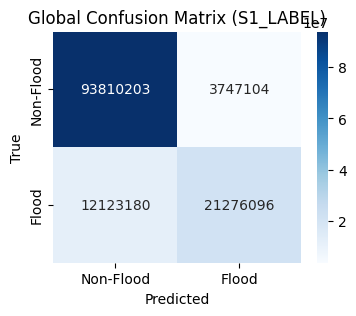

,sample_id,precision,recall,f1
0,selected_Gatineau_2019-05-19,0.999988,0.509063,0.674672
1,selected_Gatineau_2019-05-26,0.494220,0.946561,0.649383
2,selected_Ottawa_2019-05-19,0.999062,0.626941,0.770420
3,selected_Ottawa_2019-05-26,0.577838,0.722067,0.641951


In [23]:
# Evaluate against the ground truth S1 labels
print("Evaluating U-Net...")
df_eval_unet = evaluate_predictions_fast(
    predictions_dict=unet_predictions, 
    samples=test_samples, 
    target="s1_label" 
)

display(df_eval_unet)